In [5]:
import pandas as pd

In [6]:
cars = pd.read_csv(
    r"C:\Users\acreddy\Desktop\ML\ML-Models\DecisionTree_Classfier_and_Reg\data\cars_preprocessed_data.csv"
)

In [7]:
cars.head(2)

,symboling,wheel_base,length,width,height,curb_weight,num_of_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0


In [8]:
X= cars.iloc[:,:-1]

In [9]:
y= cars.iloc[:, -1]

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
# split the data into train and test
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.25, random_state=42)

In [12]:
X_train.shape,   y_train.shape

((153, 15), (153,))

In [13]:
X_test.shape, y_test.shape

((52, 15), (52,))

# Decision Tree Regressor

In [14]:
from sklearn.tree import DecisionTreeRegressor

In [15]:
# initialize the decision tree regressor
# here i have taken default criterion="squared_error". 
# you can use criterion: {“squared_error”, “friedman_mse”, “absolute_error”, “poisson”}
regressor= DecisionTreeRegressor()

In [16]:
# fit on train data
regressor.fit(X_train, y_train)

DecisionTreeRegressor()

In [17]:
# we can see the tree also how our decision Tree built a tree
# but its gonna too many calculations and too many features. So hard to plot 
from sklearn import tree
import matplotlib.pyplot as plt

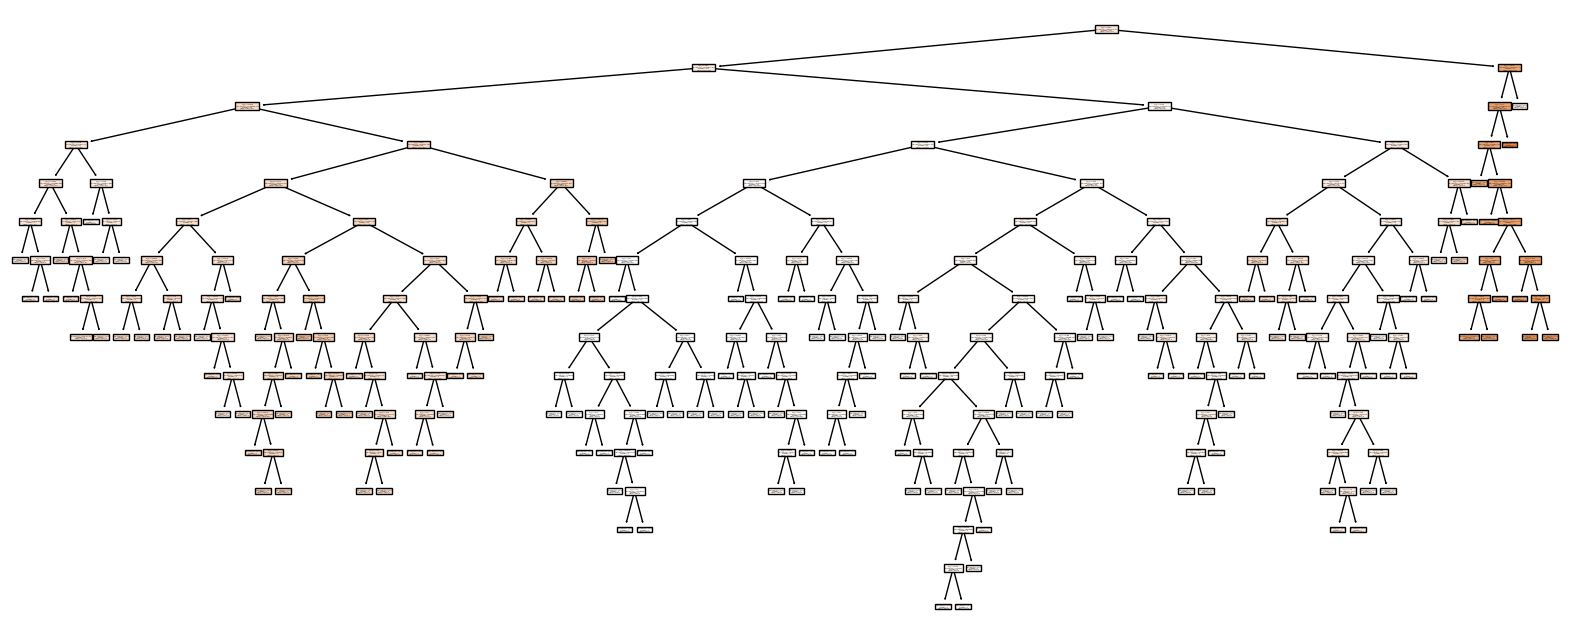

In [18]:
plt.figure(figsize=(20, 8))
tree.plot_tree(regressor, filled=True)
plt.show()

In [19]:
# predictions
y_pred= regressor.predict(X_test)

In [20]:
# lets get the metrics
from sklearn.metrics import r2_score, mean_squared_error

In [21]:
r_square= r2_score(y_test, y_pred)
mse= mean_squared_error(y_test, y_pred)

In [22]:
r_square

0.8793456790552636

In [23]:
mse

8102474.903846154

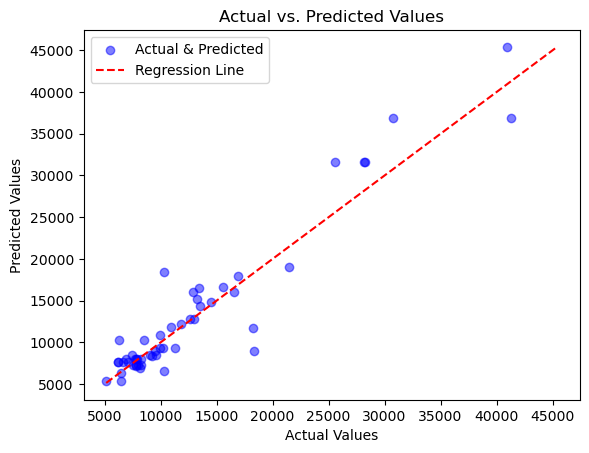

In [24]:
# lets plot how the model is fit on the data
plt.scatter(y_test, y_pred, color="blue", alpha=0.5, label="Actual & Predicted")

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Regression Line")


plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend()

# Show the plot
plt.show()

In [25]:
# Adjusted R-Square
R2_adjust = 1 - (1 - r_square) * (len(cars) - 1) / (len(cars) - X.shape[1] - 1)
R2_adjust

0.8697699392977449

Note: r_square and Adjusted R_square both have better scores in Decision Tree Regressor than in Linear Regression we built earlier.

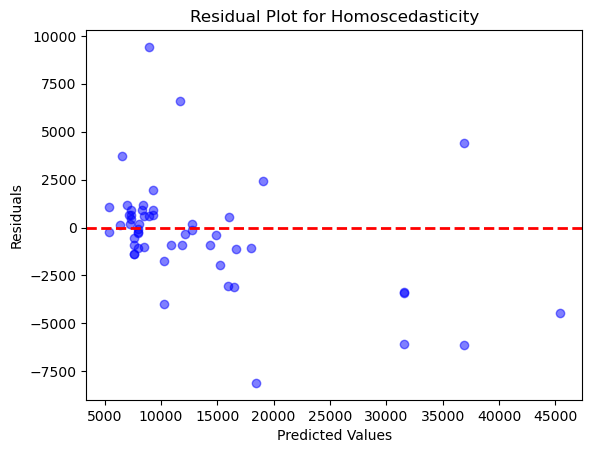

In [26]:
# check the homoscedacity and heteroscedacity using the Residual plot

residuals= y_test - y_pred

plt.scatter(y_pred, residuals, color= "blue", alpha=0.5)
plt.axhline(y=0, color="red", linestyle= "--", linewidth=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot for Homoscedasticity")
plt.show()

Note: residuals are not uniformly scattered. So its not showing up any homescedasticity. 

# Post-Pruning 

Note:  The above regressor tree gone to max depth. lets control it by pruning the branches

In [27]:
regressor_pruning= DecisionTreeRegressor(max_depth=9)

In [28]:
regressor_pruning.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=9)

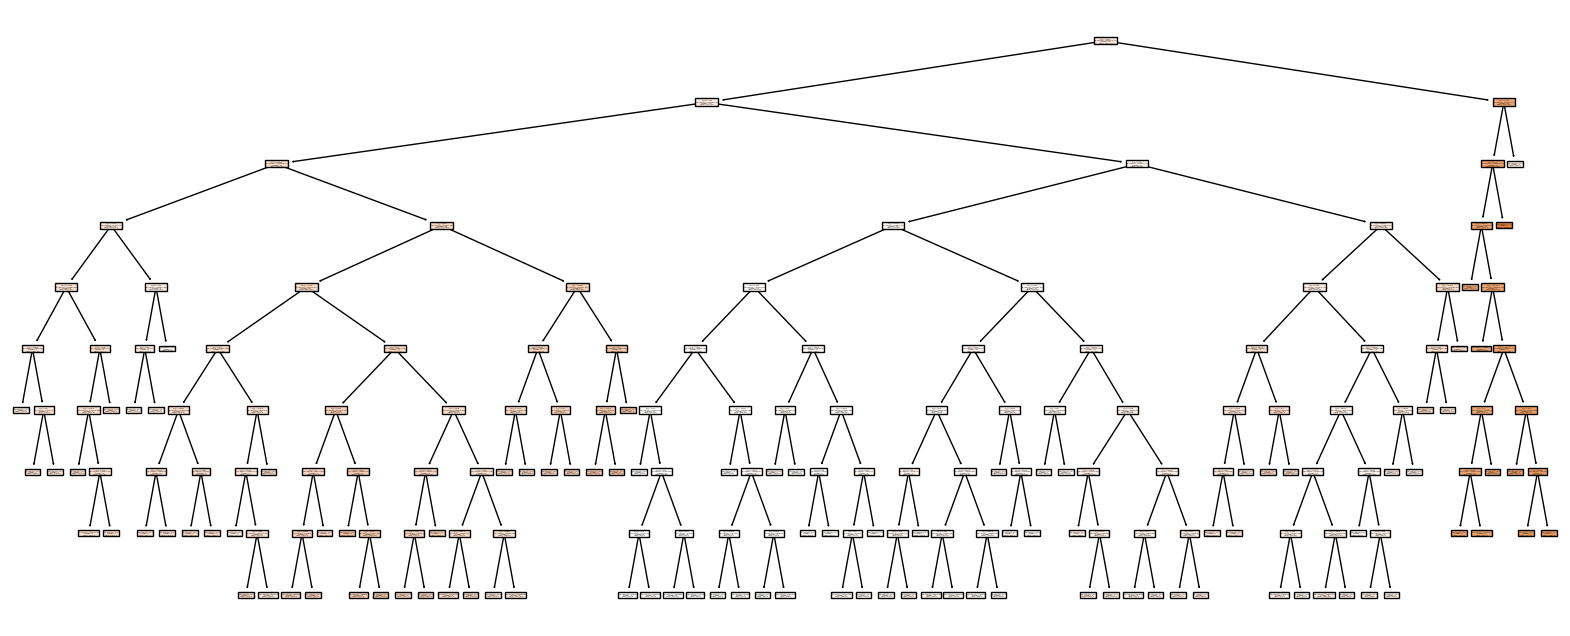

In [29]:
plt.figure(figsize=(20, 8))
tree.plot_tree(regressor_pruning, filled=True)
plt.show()

In [30]:
# predictions
y_pred_pruning= regressor_pruning.predict(X_test)

In [31]:
# lets get the metrics
r_square_pruning = r2_score(y_test, y_pred_pruning)
mse_pruning  = mean_squared_error(y_test, y_pred_pruning)

In [32]:
r_square_pruning

0.8840084914762758

In [33]:
mse_pruning

7789346.2870940175

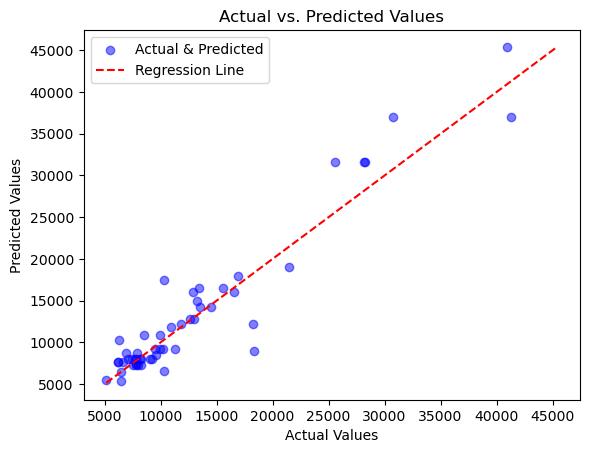

In [34]:
# lets plot how the model is fit on the data
plt.scatter(y_test, y_pred_pruning, color="blue", alpha=0.5, label="Actual & Predicted")

min_val = min(min(y_test), min(y_pred_pruning))
max_val = max(max(y_test), max(y_pred_pruning))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Regression Line",
)


plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend()

# Show the plot
plt.show()

# Model Explainability (TreeSHAP)

In [35]:
import shap

explainer = shap.TreeExplainer(regressor_pruning)

shap_values = explainer(X_test.iloc[[0]])

In [37]:
# shap values
print(shap_values)

.values =
array([[-2.76646663e+01, -4.28302177e-01,  7.93846403e+02,
         9.92482807e+02, -1.38269477e+02,  1.39296031e+03,
         0.00000000e+00,  1.89854016e+04, -6.97086615e+02,
        -2.85814306e+02, -1.60878685e+00,  1.79881600e+02,
         9.59729055e+02,  1.95291725e+01,  1.61662294e+03]])

.base_values =
array([13238.41830065])

.data =
array([[0.000e+00, 1.035e+02, 1.890e+02, 6.690e+01, 5.570e+01, 3.230e+03,
        6.000e+00, 2.090e+02, 3.620e+00, 3.390e+00, 8.000e+00, 1.820e+02,
        5.400e+03, 1.600e+01, 2.200e+01]])


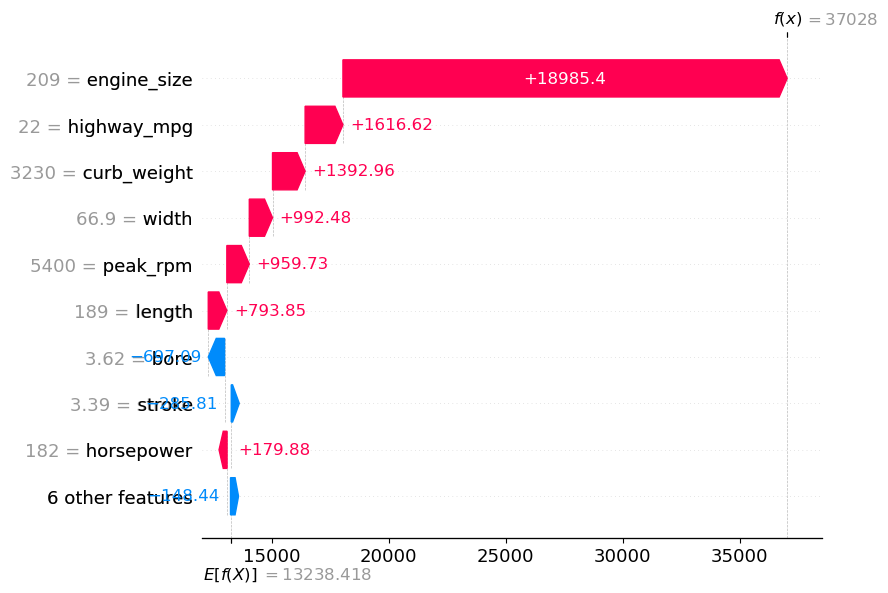

In [38]:
shap.plots.waterfall(shap_values[0])